In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from tqdm import tqdm

In [3]:
beta = 1 # parametr rozkładu Beta(theta, beta)
ns = [20, 50, 100] 
thetas = [0.5, 1, 2, 5] 
T = 10**4

In [4]:
import os

BASE_DIR = '../plots/zad2' 
os.makedirs(BASE_DIR, exist_ok=True)
plot_dir = os.path.join(BASE_DIR, 'wyniki_wykresy')
os.makedirs(plot_dir, exist_ok=True)
print(f"Przygotowano foldery w: {BASE_DIR}")

Przygotowano foldery w: ../plots/zad2


In [5]:
def gen_sample(n, theta, beta):
    """Generuje próbę z rozkładu Beta(theta, beta)."""
    s = np.random.beta(theta, beta, n)
    return s

In [6]:
def estimator_theta(xs):
  return -1.0 / np.log(xs).mean()

def estimator_fisher(xs):
  sum = np.sum(np.log(xs))
  return sum ** 2 / len(xs)

In [7]:
def plot_results(data, true_theta, n, asymp_var):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f'Wyniki dla theta = {true_theta} i n = {n}', fontsize=16)

    # 1. Wykres Pudełkowy
    axes[0].boxplot(data)
    axes[0].axhline(true_theta, color='red', linestyle='--', label=f'Prawdziwe theta = {true_theta}')
    axes[0].set_title('Wykres Pudełkowy Estymatora theta_hat')
    axes[0].set_xlabel('Estymator')
    axes[0].set_ylabel('Wartość')
    axes[0].legend()

    # 2. Histogram i gęstość asymptotyczna
    mu_asymp = true_theta # Średnia asymptotyczna to prawdziwa wartość
    scale_asymp = np.sqrt(asymp_var) # Odchylenie std. to sqrt(wariancja)

    axes[1].hist(data, bins=50, density=True, alpha=0.7, label='Histogram theta_hat')
    # Rysowanie gęstości asymptotycznej (chcemy sprawdzić czy asympotytczny jest noramlny, więc to rysujemy)
    x_min, x_max = axes[1].get_xlim()
    x_vals = np.linspace(x_min, x_max, 200)
    pdf_vals = stats.norm.pdf(x_vals, loc=mu_asymp, scale=scale_asymp)
    axes[1].plot(x_vals, pdf_vals, 'r-', linewidth=2, label=f'Rozk. Asymptotyczny N(theta, 1 / avg_I_hat)')

    axes[1].set_title('Histogram i Gęstość Asymptotyczna')
    axes[1].set_xlabel('Wartość theta_hat')
    axes[1].set_ylabel('Gęstość')
    axes[1].legend()

    # 3. Wykres Kwantylowo-Kwantylowy (Q-Q)
    stats.probplot(data, dist="norm", sparams=(mu_asymp, scale_asymp), plot=axes[2])
    axes[2].set_title('Wykres Q-Q vs Rozkład Normalny')
    # Usuwamy domyślny tytuł z probplot
    axes[2].get_lines()[0].set_markerfacecolor('b')
    axes[2].get_lines()[0].set_markersize(2.0)
    axes[2].get_lines()[1].set_color('r')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    filename = os.path.join(plot_dir, f'results_theta_{true_theta}_n_{n}.png')
    plt.savefig(filename)
    
    plt.show()
    plt.close()
    print(f"Zapisano wykres do: {filename}")


--- Rozpoczynam symulację dla: theta = 0.5, n = 20 ---


Sim: t=0.5, n=20:   0%|          | 0/10000 [00:00<?, ?it/s]

Sim: t=0.5, n=20: 100%|██████████| 10000/10000 [00:00<00:00, 145095.48it/s]

Prawdziwa theta: 0.5, Średnia theta_hat: 0.5255
Teoretyczna wariancja asymp. (theta^2/n): 0.012500
Estymowana wariancja asymp. est (1 / avg_I_hat_): 0.011880


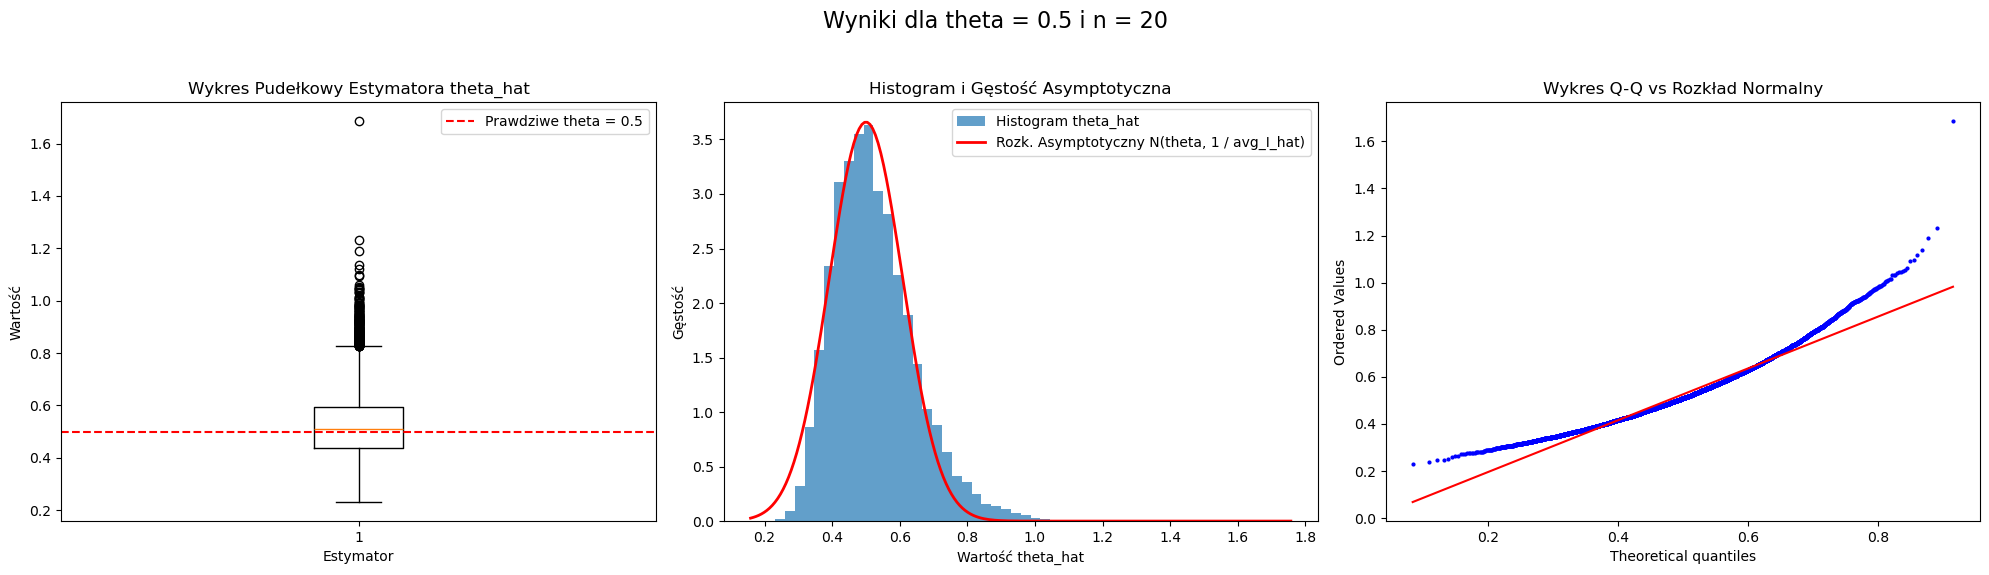

Zapisano wykres do: ../plots/zad2/wyniki_wykresy/results_theta_0.5_n_20.png

--- Rozpoczynam symulację dla: theta = 0.5, n = 50 ---


Sim: t=0.5, n=50: 100%|██████████| 10000/10000 [00:00<00:00, 122142.26it/s]

Prawdziwa theta: 0.5, Średnia theta_hat: 0.5099
Teoretyczna wariancja asymp. (theta^2/n): 0.005000
Estymowana wariancja asymp. est (1 / avg_I_hat_): 0.004895


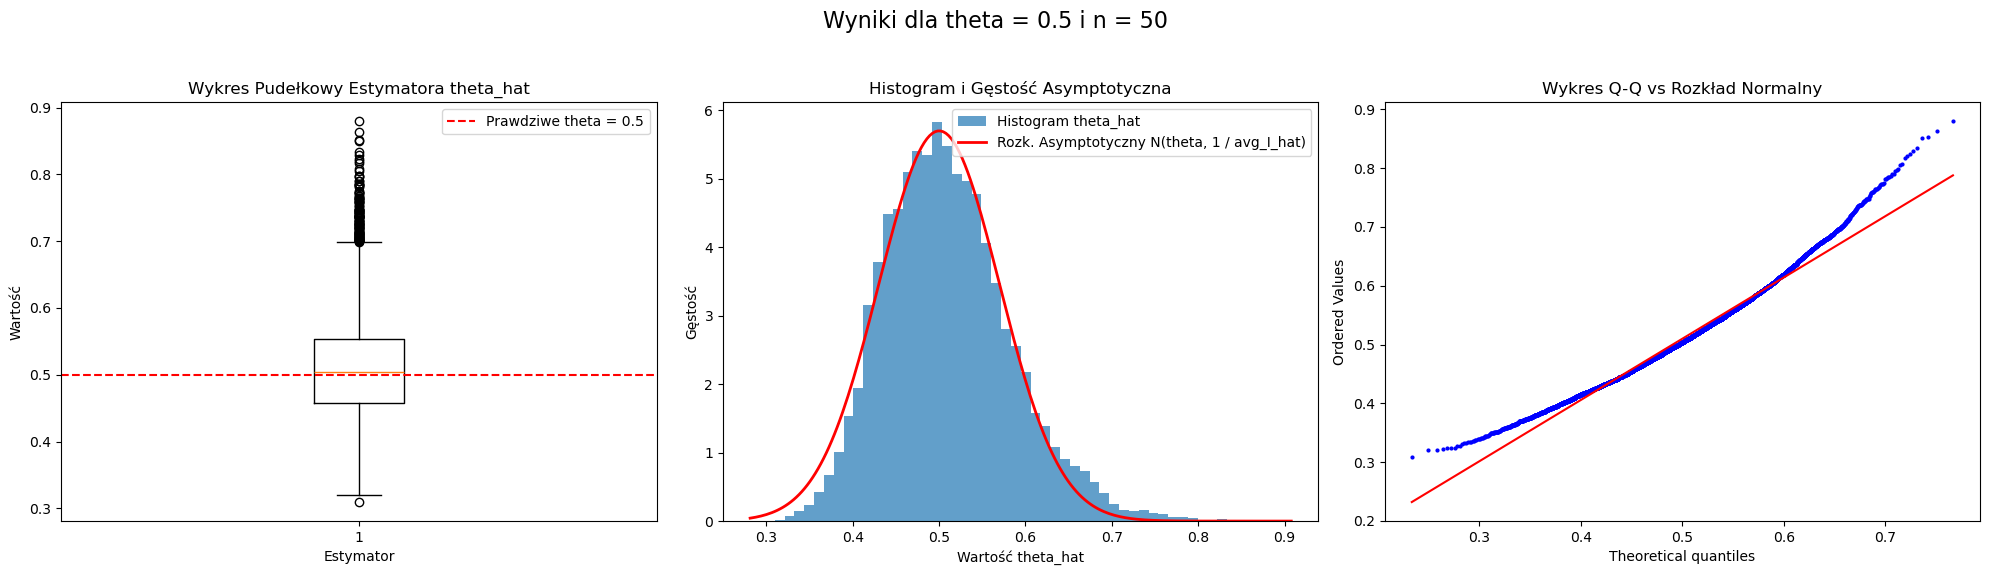

Zapisano wykres do: ../plots/zad2/wyniki_wykresy/results_theta_0.5_n_50.png

--- Rozpoczynam symulację dla: theta = 0.5, n = 100 ---


Sim: t=0.5, n=100: 100%|██████████| 10000/10000 [00:00<00:00, 91221.17it/s]

Prawdziwa theta: 0.5, Średnia theta_hat: 0.5044
Teoretyczna wariancja asymp. (theta^2/n): 0.002500
Estymowana wariancja asymp. est (1 / avg_I_hat_): 0.002470


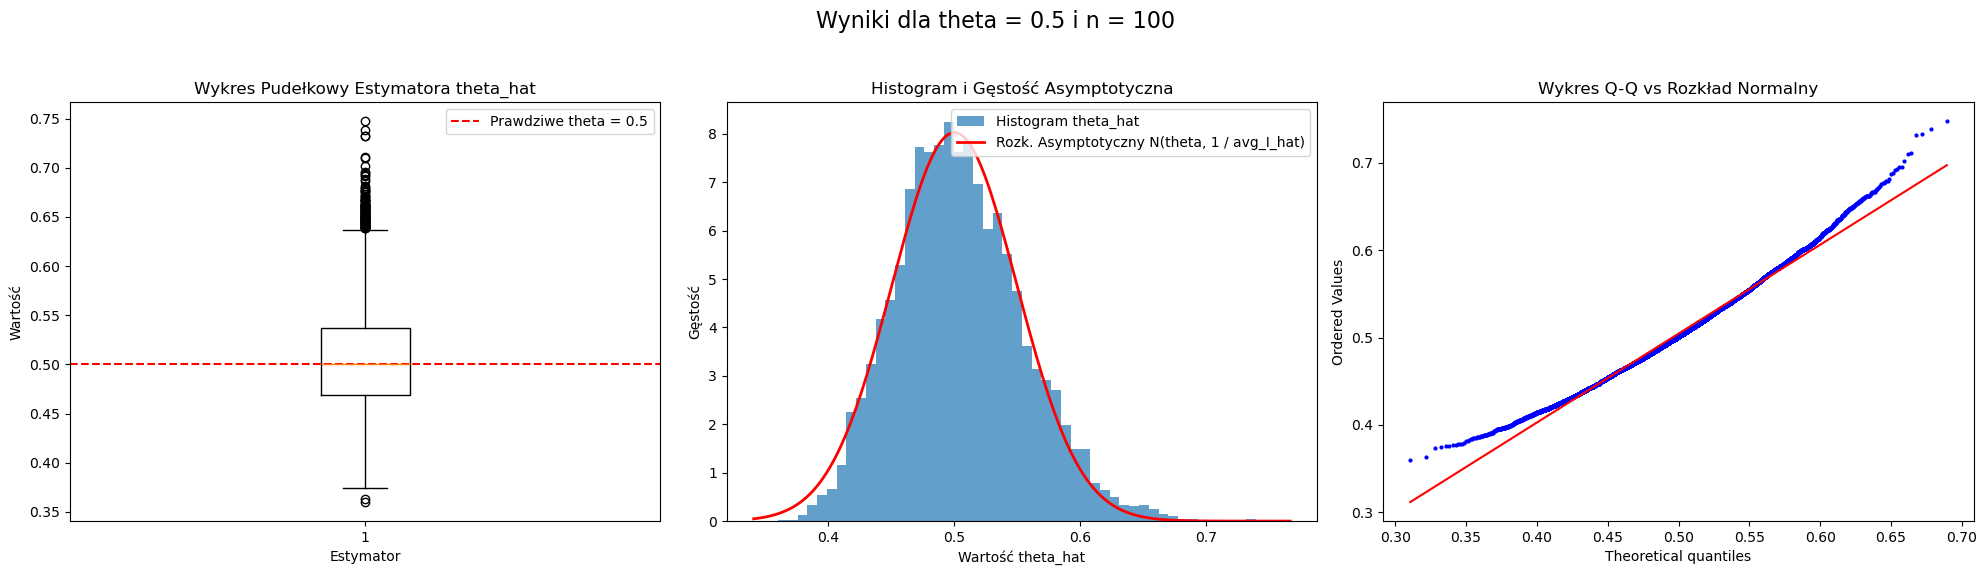

Zapisano wykres do: ../plots/zad2/wyniki_wykresy/results_theta_0.5_n_100.png

--- Rozpoczynam symulację dla: theta = 1, n = 20 ---


Sim: t=1, n=20: 100%|██████████| 10000/10000 [00:00<00:00, 135422.01it/s]

Prawdziwa theta: 1, Średnia theta_hat: 1.0501
Teoretyczna wariancja asymp. (theta^2/n): 0.050000
Estymowana wariancja asymp. est (1 / avg_I_hat_): 0.047375


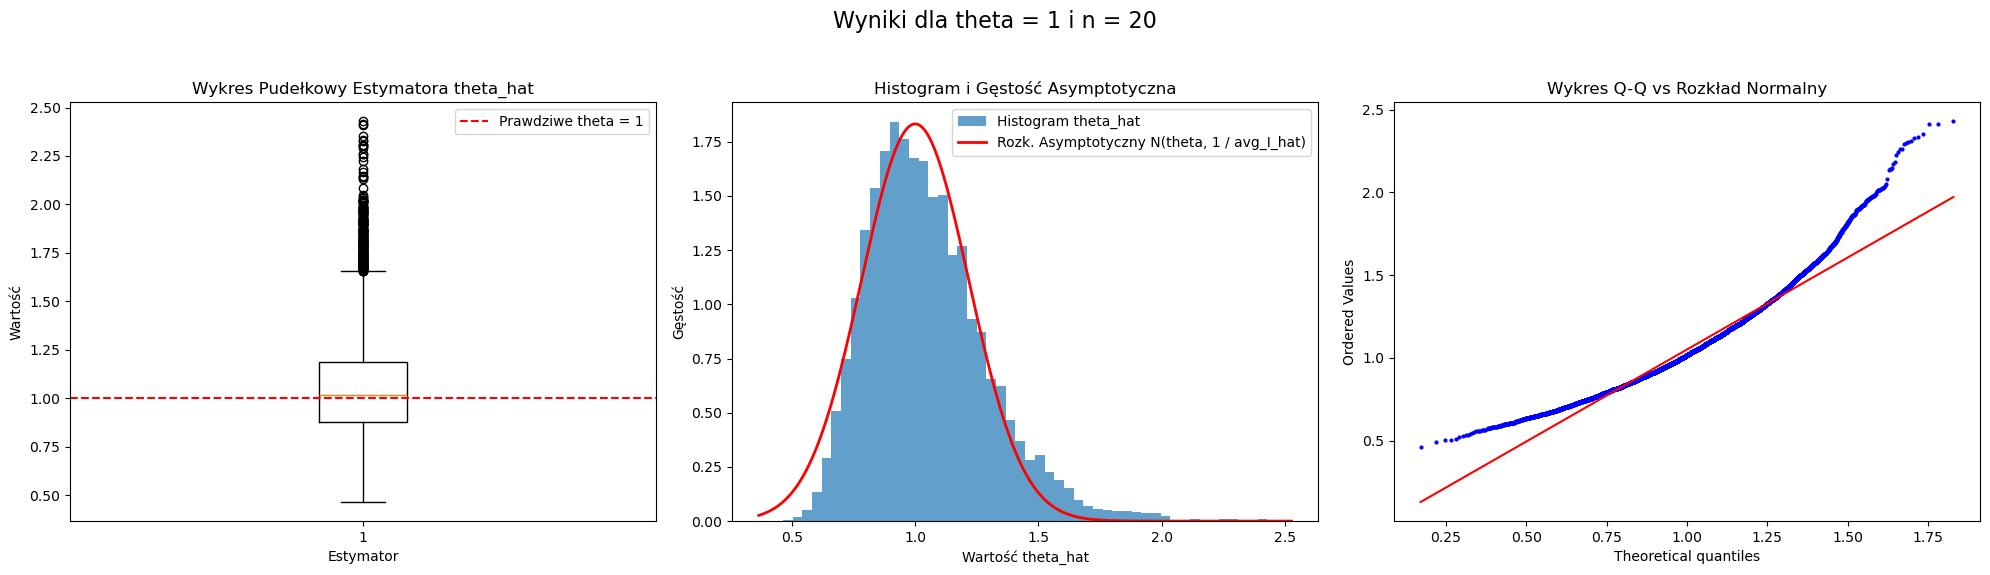

Zapisano wykres do: ../plots/zad2/wyniki_wykresy/results_theta_1_n_20.png

--- Rozpoczynam symulację dla: theta = 1, n = 50 ---


Sim: t=1, n=50: 100%|██████████| 10000/10000 [00:00<00:00, 93336.39it/s]

Prawdziwa theta: 1, Średnia theta_hat: 1.0190
Teoretyczna wariancja asymp. (theta^2/n): 0.020000
Estymowana wariancja asymp. est (1 / avg_I_hat_): 0.019595


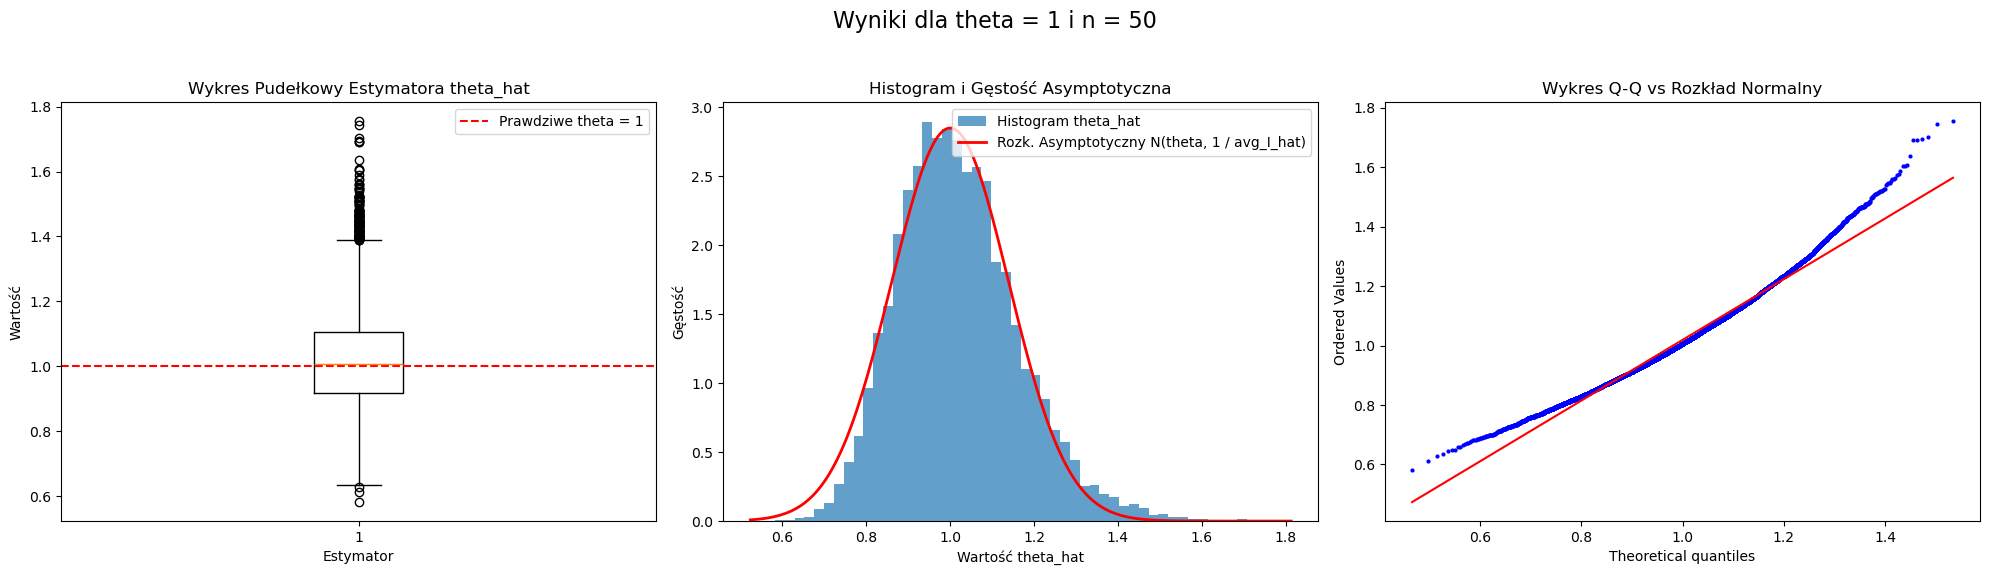

Zapisano wykres do: ../plots/zad2/wyniki_wykresy/results_theta_1_n_50.png

--- Rozpoczynam symulację dla: theta = 1, n = 100 ---


Sim: t=1, n=100: 100%|██████████| 10000/10000 [00:00<00:00, 73889.17it/s]

Prawdziwa theta: 1, Średnia theta_hat: 1.0092
Teoretyczna wariancja asymp. (theta^2/n): 0.010000
Estymowana wariancja asymp. est (1 / avg_I_hat_): 0.009872


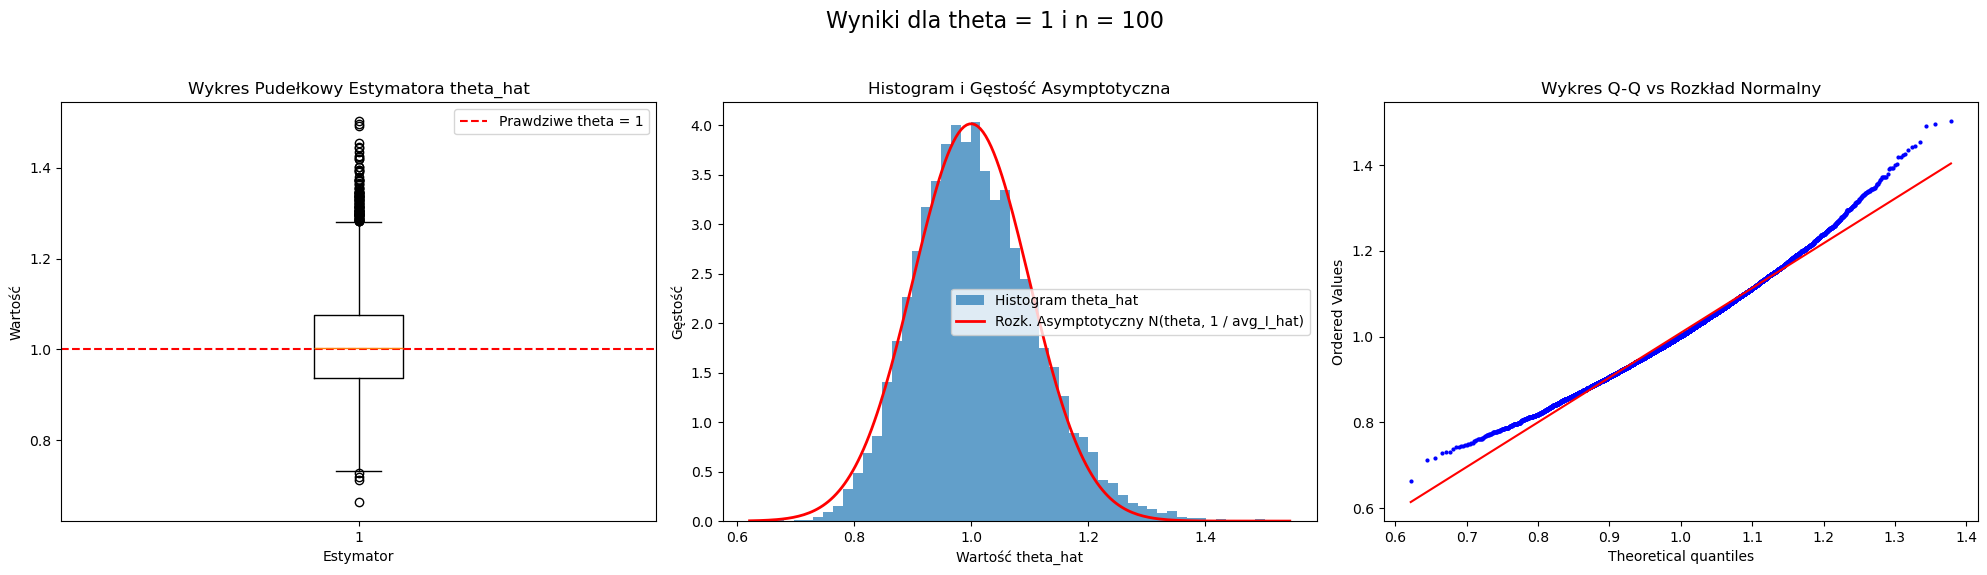

Zapisano wykres do: ../plots/zad2/wyniki_wykresy/results_theta_1_n_100.png

--- Rozpoczynam symulację dla: theta = 2, n = 20 ---


Sim: t=2, n=20: 100%|██████████| 10000/10000 [00:00<00:00, 167418.57it/s]

Prawdziwa theta: 2, Średnia theta_hat: 2.1106
Teoretyczna wariancja asymp. (theta^2/n): 0.200000
Estymowana wariancja asymp. est (1 / avg_I_hat_): 0.191222


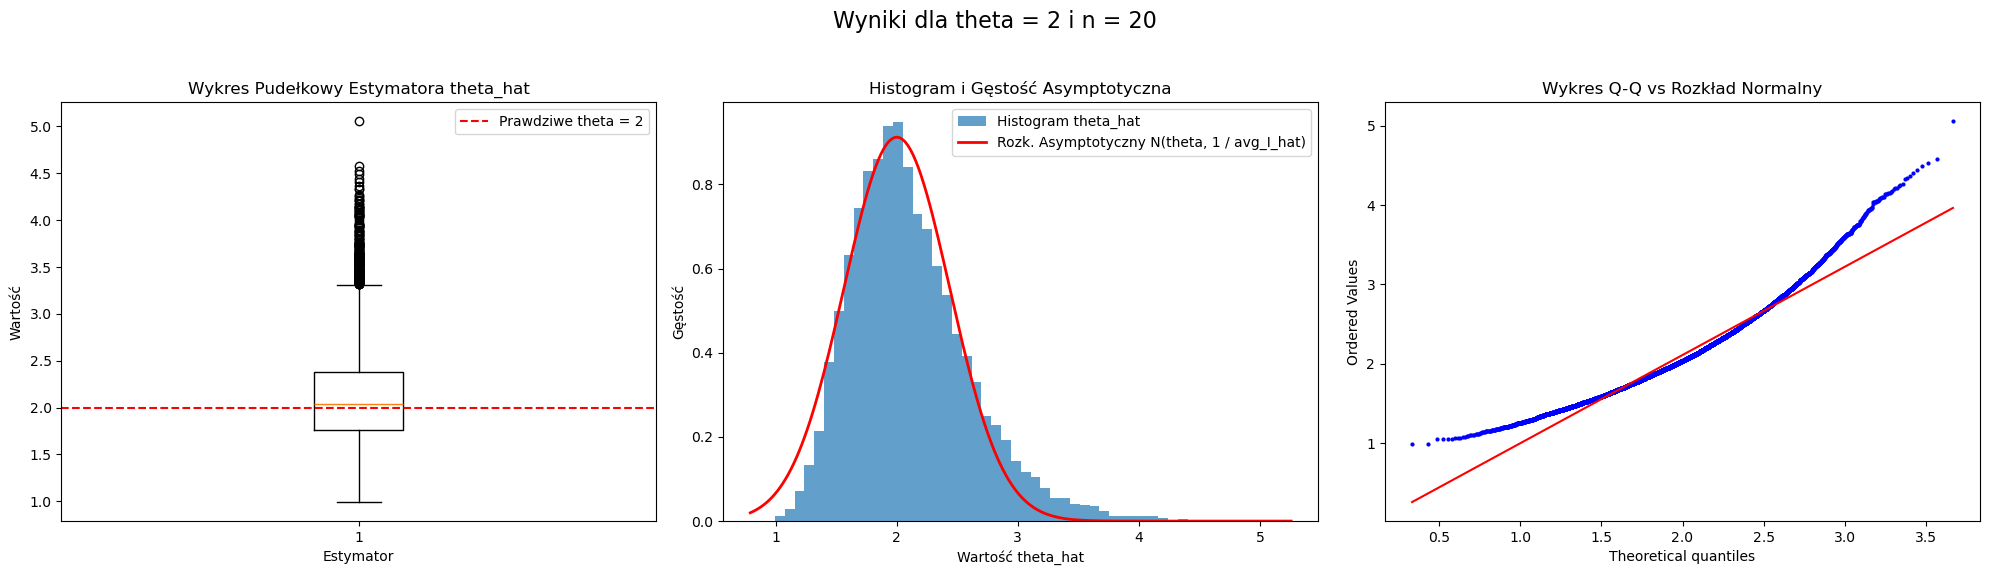

Zapisano wykres do: ../plots/zad2/wyniki_wykresy/results_theta_2_n_20.png

--- Rozpoczynam symulację dla: theta = 2, n = 50 ---


Sim: t=2, n=50: 100%|██████████| 10000/10000 [00:00<00:00, 114752.41it/s]

Prawdziwa theta: 2, Średnia theta_hat: 2.0444
Teoretyczna wariancja asymp. (theta^2/n): 0.080000
Estymowana wariancja asymp. est (1 / avg_I_hat_): 0.078636


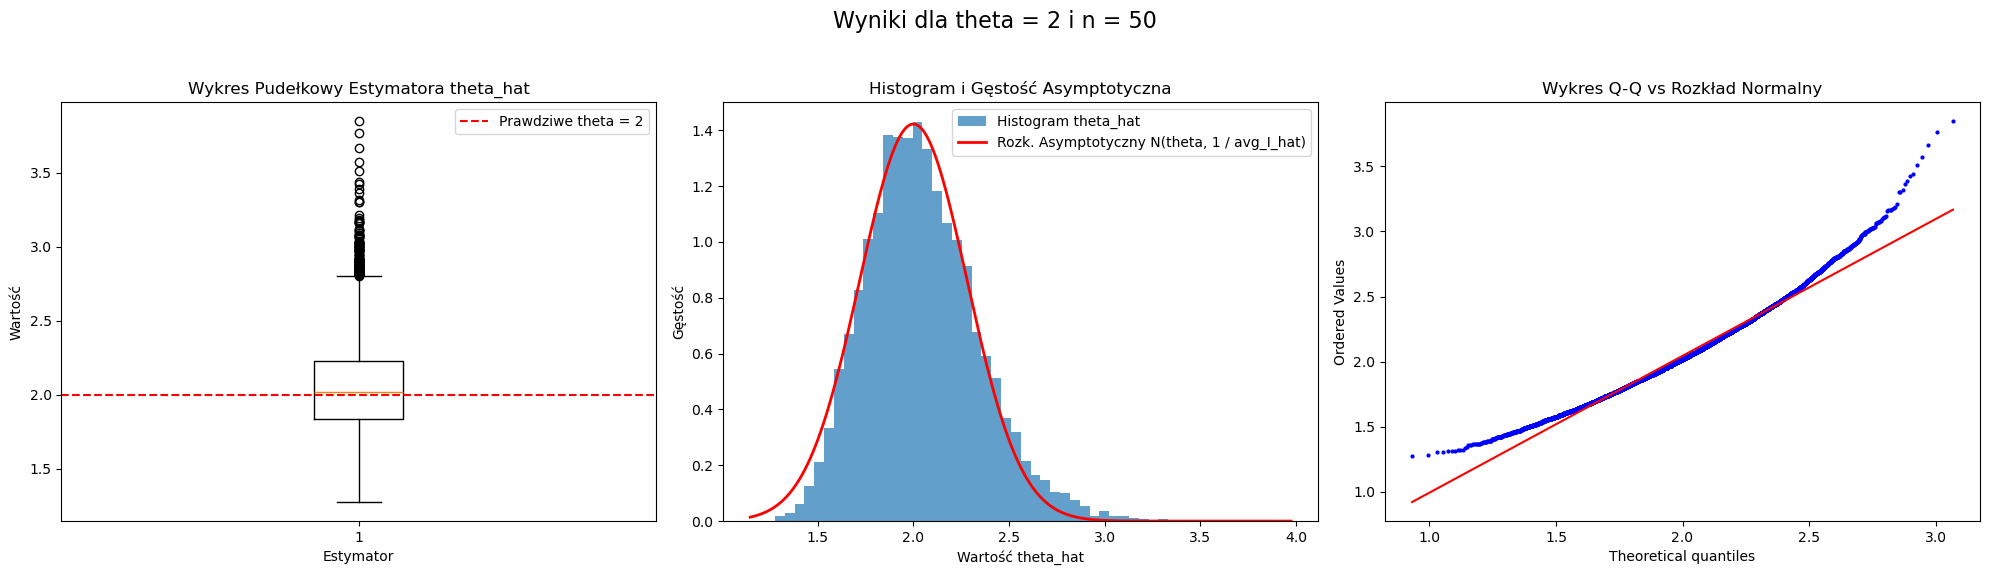

Zapisano wykres do: ../plots/zad2/wyniki_wykresy/results_theta_2_n_50.png

--- Rozpoczynam symulację dla: theta = 2, n = 100 ---


Sim: t=2, n=100: 100%|██████████| 10000/10000 [00:00<00:00, 102917.10it/s]

Prawdziwa theta: 2, Średnia theta_hat: 2.0147
Teoretyczna wariancja asymp. (theta^2/n): 0.040000
Estymowana wariancja asymp. est (1 / avg_I_hat_): 0.039398


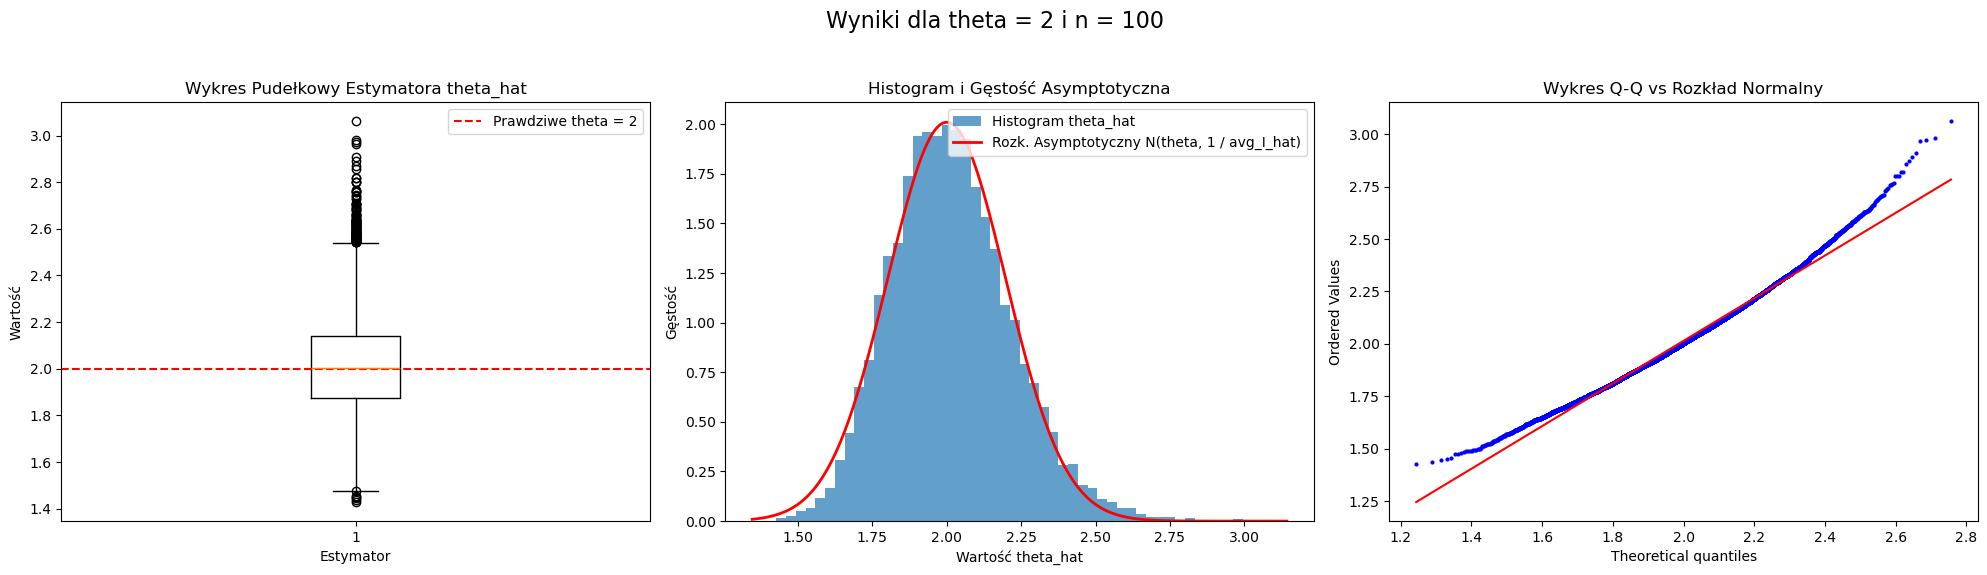

Zapisano wykres do: ../plots/zad2/wyniki_wykresy/results_theta_2_n_100.png

--- Rozpoczynam symulację dla: theta = 5, n = 20 ---


Sim: t=5, n=20: 100%|██████████| 10000/10000 [00:00<00:00, 129350.83it/s]

Prawdziwa theta: 5, Średnia theta_hat: 5.2468
Teoretyczna wariancja asymp. (theta^2/n): 1.250000
Estymowana wariancja asymp. est (1 / avg_I_hat_): 1.187549


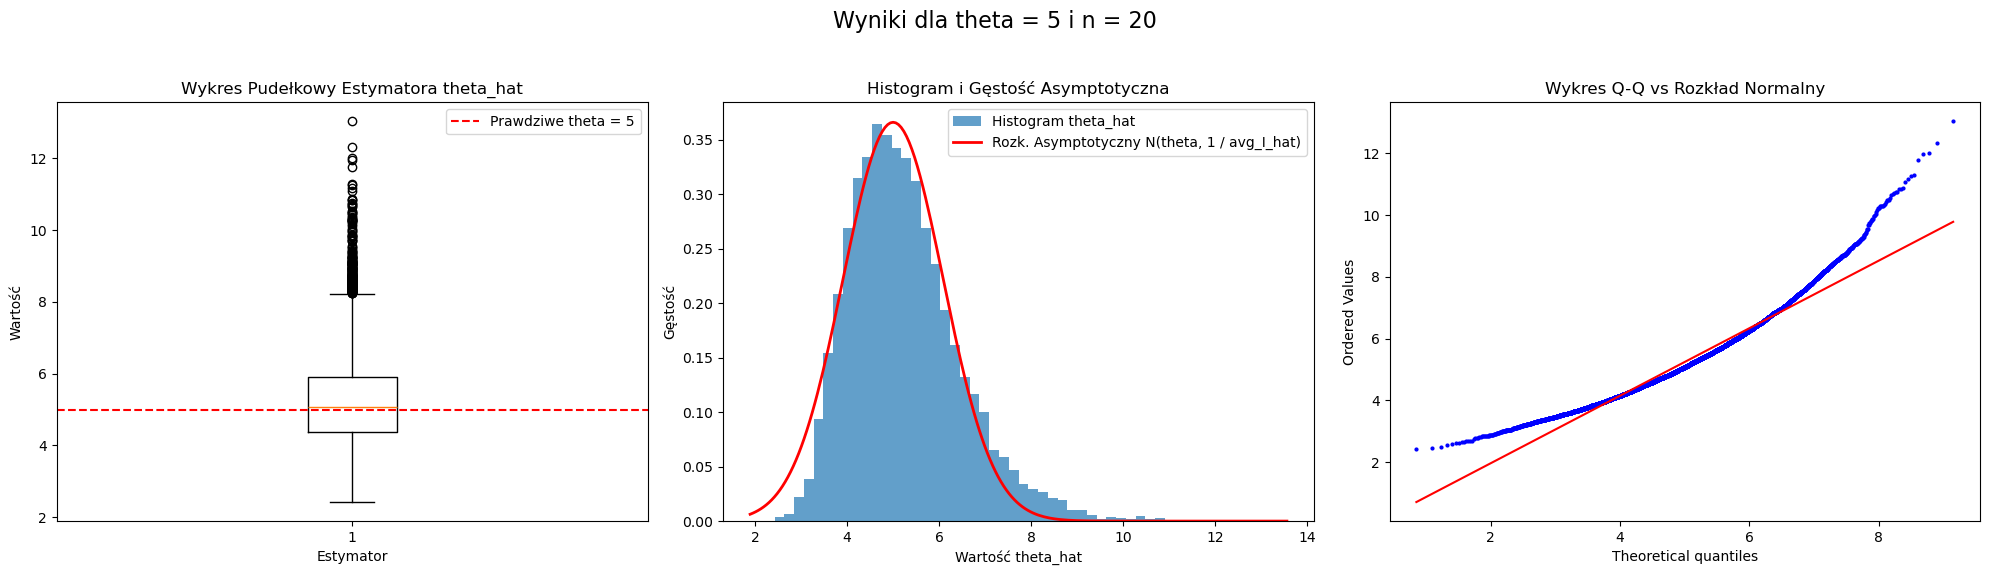

Zapisano wykres do: ../plots/zad2/wyniki_wykresy/results_theta_5_n_20.png

--- Rozpoczynam symulację dla: theta = 5, n = 50 ---


Sim: t=5, n=50: 100%|██████████| 10000/10000 [00:00<00:00, 129654.31it/s]

Prawdziwa theta: 5, Średnia theta_hat: 5.1091
Teoretyczna wariancja asymp. (theta^2/n): 0.500000
Estymowana wariancja asymp. est (1 / avg_I_hat_): 0.491776


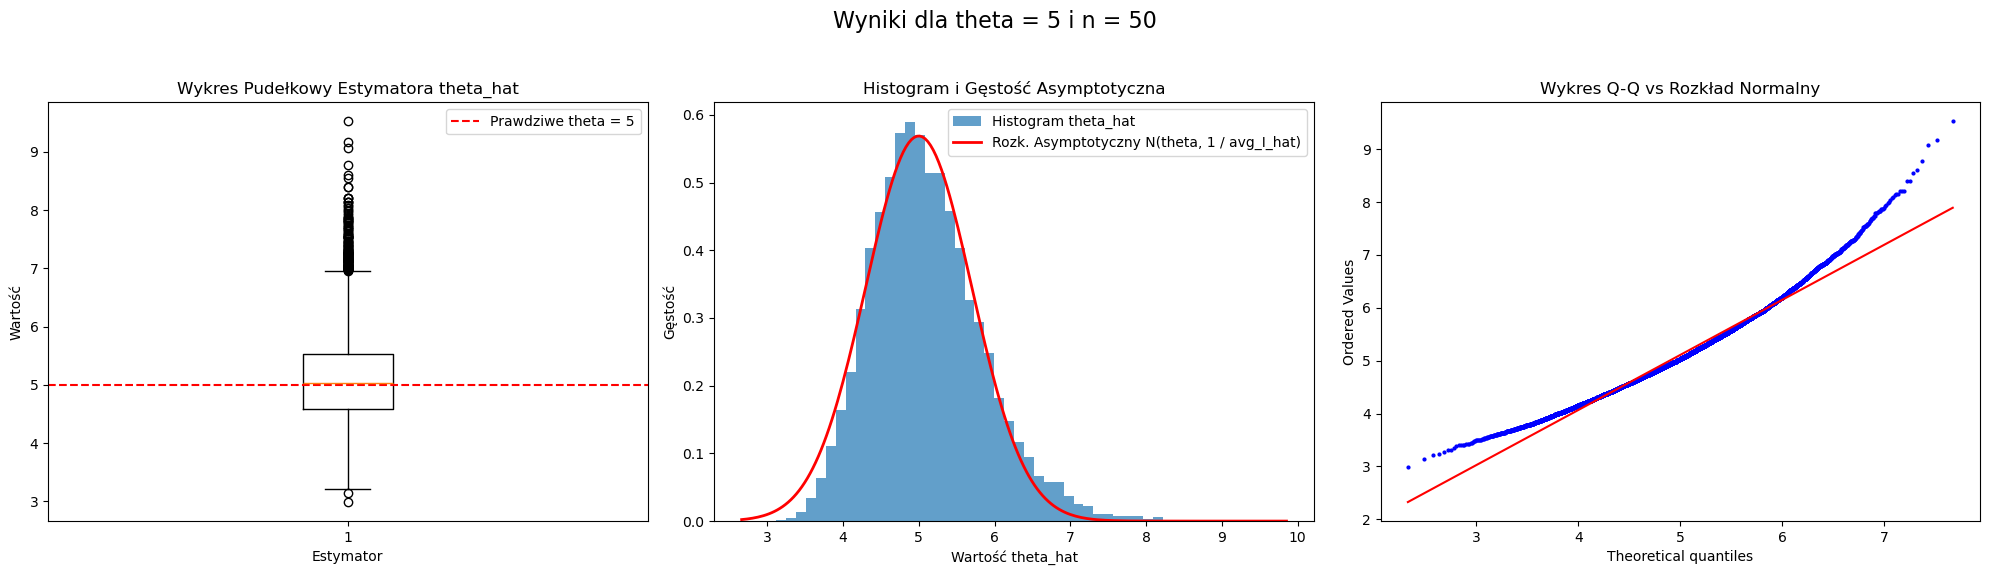

Zapisano wykres do: ../plots/zad2/wyniki_wykresy/results_theta_5_n_50.png

--- Rozpoczynam symulację dla: theta = 5, n = 100 ---


Sim: t=5, n=100: 100%|██████████| 10000/10000 [00:00<00:00, 91634.51it/s]

Prawdziwa theta: 5, Średnia theta_hat: 5.0523
Teoretyczna wariancja asymp. (theta^2/n): 0.250000
Estymowana wariancja asymp. est (1 / avg_I_hat_): 0.247667


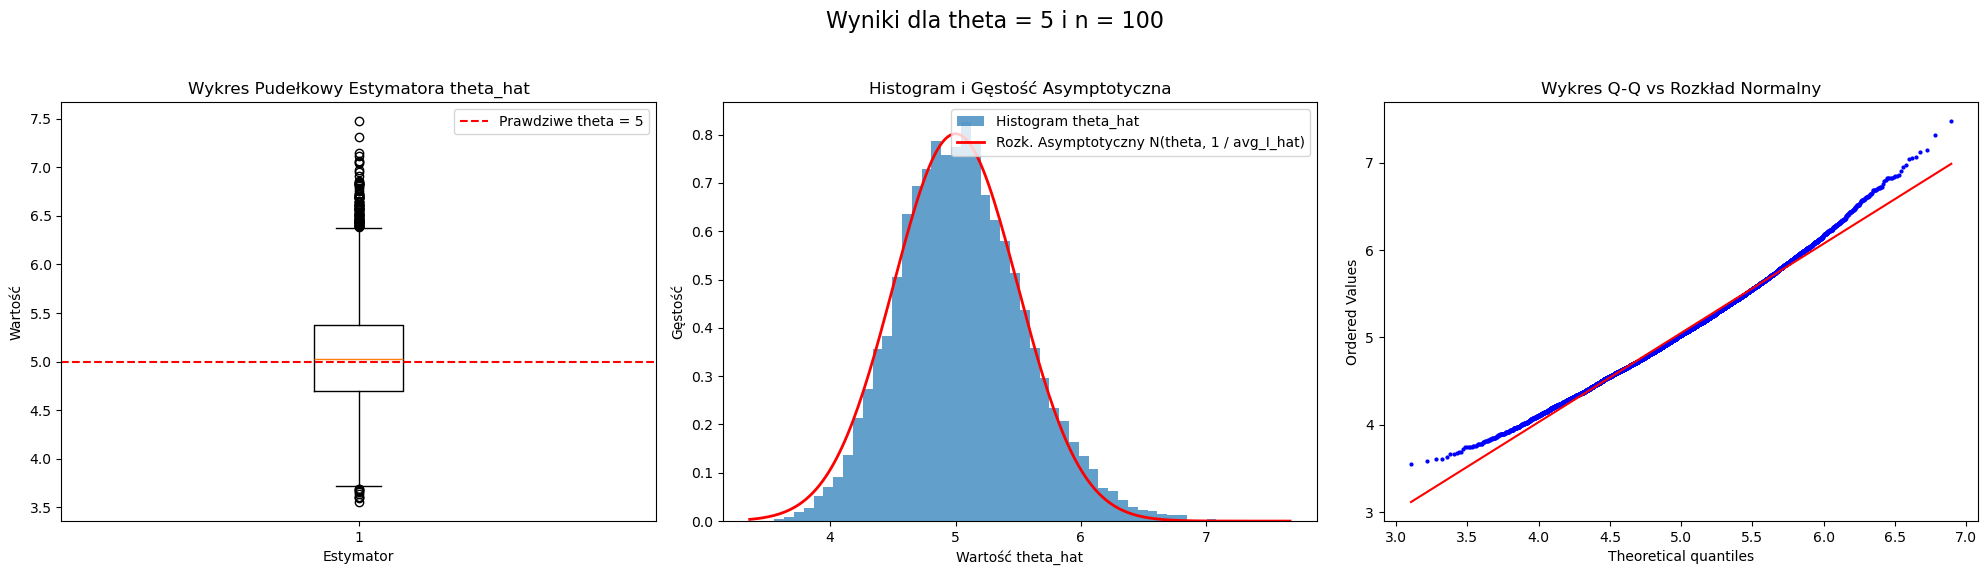

Zapisano wykres do: ../plots/zad2/wyniki_wykresy/results_theta_5_n_100.png


In [8]:
stats_list = []

for theta in thetas:
    for n in ns:
        print(f"\n--- Rozpoczynam symulację dla: theta = {theta}, n = {n} ---")

        theta_hats = np.zeros(T)
        fisher_hats = np.zeros(T)

        for i in tqdm(range(T), desc=f"Sim: t={theta}, n={n}"):
            xs = gen_sample(n, theta, beta)
            theta_hats[i] = estimator_theta(xs)
            fisher_hats[i] = estimator_fisher(xs)

        avg_I_hat = np.mean(fisher_hats)

        # Teoretyczna informacja Fishera to I_n(theta) = n / theta^2
        # Wariancja asymptotyczna to [I_n(theta)]^-1 = theta^2 / n
        # Zobaczmy, jak blisko jest nasz estymowany 1 / avg_I_hat

        # Używamy tej zapamiętanej wartości do oszacowania wariancji asymptotycznej
        # Wariancja = 1 / I_n
        avg_I_hat = np.mean(fisher_hats)
        asymptotic_variance = 1.0 / avg_I_hat
        mean_theta_hat = np.mean(theta_hats)

        print(f"Prawdziwa theta: {theta}, Średnia theta_hat: {np.mean(theta_hats):.4f}")
        print(f"Teoretyczna wariancja asymp. (theta^2/n): {(theta**2 / n):.6f}")
        print(f"Estymowana wariancja asymp. est (1 / avg_I_hat_): {asymptotic_variance:.6f}")

        stats_list.append({
            'theta_true': theta,
            'n': n,
            'mean_theta_hat': mean_theta_hat,
            'bias': mean_theta_hat - theta,
            'var_asymp_theo': theta**2 / n,
            'var_asymp_est': asymptotic_variance,
            'var_simulacji': np.var(theta_hats)
        })

        plot_results(theta_hats, theta, n, asymptotic_variance)


In [9]:
import pandas as pd

if stats_list:
    stats_df = pd.DataFrame(stats_list)
    stats_df = stats_df.round(3)
    stats_file = os.path.join(BASE_DIR, 'podsumowanie_statystyk.csv')
    stats_df.to_csv(stats_file, index=False)
    print("\n--- Podsumowanie Statystyk ---")
    print(stats_df)
    print(f"\nZapisano tabelę statystyk do: {stats_file}")


--- Podsumowanie Statystyk ---
    theta_true    n  mean_theta_hat   bias  var_asymp_theo  var_asymp_est  \
0          0.5   20           0.526  0.026           0.012          0.012   
1          0.5   50           0.510  0.010           0.005          0.005   
2          0.5  100           0.504  0.004           0.002          0.002   
3          1.0   20           1.050  0.050           0.050          0.047   
4          1.0   50           1.019  0.019           0.020          0.020   
5          1.0  100           1.009  0.009           0.010          0.010   
6          2.0   20           2.111  0.111           0.200          0.191   
7          2.0   50           2.044  0.044           0.080          0.079   
8          2.0  100           2.015  0.015           0.040          0.039   
9          5.0   20           5.247  0.247           1.250          1.188   
10         5.0   50           5.109  0.109           0.500          0.492   
11         5.0  100           5.052  0.052  